In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import PowerNorm


plt.rcParams["figure.dpi"] = 120


def load_conv_dataset(path):
    data = np.load(path)
    if data.ndim == 3:
        data = data[:, None, :, :]
    if data.ndim != 4:
        raise ValueError(f"Expected (N, C, H, W) or (N, H, W), got {data.shape}")
    if data.shape[-1] != data.shape[-2]:
        raise ValueError(f"Expected square images, got {data.shape[-2:]}")
    return data.astype(np.float32, copy=False)


def channel_labels(data, names=None):
    channels = data.shape[1]
    if names is None:
        return [f"ch{c}" for c in range(channels)]
    if len(names) != channels:
        raise ValueError(f"Need {channels} channel names, got {len(names)}")
    return list(names)


def select_indices(total, count=16, start=0, random=False, seed=None):
    count = min(count, total)
    if random:
        rng = np.random.default_rng(seed)
        return np.sort(rng.choice(total, size=count, replace=False))
    return np.arange(start, min(total, start + count))


def get_display_limits(image, floor_percentile=50, ceil_percentile=99.7):
    positive = image[image > 0]
    if positive.size == 0:
        return 0.0, 1.0
    vmin = float(np.percentile(positive, floor_percentile))
    vmax = float(np.percentile(positive, ceil_percentile))
    if vmax <= vmin:
        vmax = float(positive.max())
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax


def get_contour_levels(image, contour_percentiles=(70, 82, 90, 96)):
    positive = image[image > 0]
    if positive.size == 0:
        return []
    levels = np.percentile(positive, contour_percentiles)
    levels = np.unique(levels[levels > 0])
    if levels.size < 2:
        return []
    return levels


def show_plain_sample(data, index=0, channel_names=None, cmap="gray"):
    labels = channel_labels(data, channel_names)
    sample = data[index]
    channels = sample.shape[0]
    fig, axes = plt.subplots(1, channels, figsize=(2.7 * channels, 2.7), squeeze=False)
    for c, ax in enumerate(axes[0]):
        im = ax.imshow(sample[c], origin="lower", cmap=cmap, interpolation="nearest")
        ax.set_title(f"#{index} | {labels[c]}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Plain sample view | shape={data.shape}", y=1.02)
    fig.tight_layout()
    plt.show()


def show_enhanced_sample(
    data,
    index=0,
    channel_names=None,
    cmap="turbo",
    gamma=0.55,
    floor_percentile=50,
    ceil_percentile=99.7,
    contour=True,
    contour_percentiles=(70, 82, 90, 96),
    contour_color="#8fd3ff",
    contour_width=0.45,
):
    labels = channel_labels(data, channel_names)
    sample = data[index]
    channels = sample.shape[0]
    fig, axes = plt.subplots(1, channels, figsize=(2.7 * channels, 2.7), squeeze=False)
    for c, ax in enumerate(axes[0]):
        image = sample[c]
        vmin, vmax = get_display_limits(image, floor_percentile, ceil_percentile)
        im = ax.imshow(
            image,
            origin="lower",
            cmap=cmap,
            norm=PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax),
            interpolation="nearest",
        )
        if contour:
            levels = get_contour_levels(image, contour_percentiles)
            if len(levels) > 0:
                ax.contour(
                    image,
                    levels=levels,
                    origin="lower",
                    colors=contour_color,
                    linewidths=contour_width,
                    alpha=0.85,
                )
        ax.set_title(f"#{index} | {labels[c]}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle("Enhanced datacheck-style view: PowerNorm + positive-percentile limits + contours", y=1.02)
    fig.tight_layout()
    plt.show()


def show_channel_batch(
    data,
    channel=0,
    indices=None,
    count=32,
    columns=8,
    random=False,
    seed=None,
    mode="enhanced",
    channel_names=None,
    cmap_plain="gray",
    cmap_enhanced="turbo",
    gamma=0.55,
    floor_percentile=50,
    ceil_percentile=99.7,
    contour=True,
    contour_percentiles=(70, 82, 90, 96),
):
    labels = channel_labels(data, channel_names)
    if indices is None:
        indices = select_indices(data.shape[0], count=count, random=random, seed=seed)
    rows = math.ceil(len(indices) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 1.8, rows * 1.8), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, idx in zip(axes.ravel(), indices):
        image = data[idx, channel]
        if mode == "plain":
            ax.imshow(image, origin="lower", cmap=cmap_plain, interpolation="nearest")
        elif mode == "enhanced":
            vmin, vmax = get_display_limits(image, floor_percentile, ceil_percentile)
            ax.imshow(
                image,
                origin="lower",
                cmap=cmap_enhanced,
                norm=PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax),
                interpolation="nearest",
            )
            if contour:
                levels = get_contour_levels(image, contour_percentiles)
                if len(levels) > 0:
                    ax.contour(image, levels=levels, origin="lower", colors="#8fd3ff", linewidths=0.45, alpha=0.85)
        else:
            raise ValueError("mode must be 'plain' or 'enhanced'")
        ax.set_title(f"#{idx}", fontsize=8)
    fig.suptitle(
        f"{mode} batch view | {labels[channel]} | shape={data.shape} | min={data.min():.4g}, max={data.max():.4g}, mean={data.mean():.4g}",
        fontsize=11,
    )
    fig.tight_layout()
    plt.show()

In [2]:
DATA_PATH = "./Evaluation/MFAexcess_300_64_test.npy"

# 4 通道或 5 通道都支持，例如：
# DATA_PATH = "your_file_with_shape_N_4_64_64.npy"
# DATA_PATH = "your_file_with_shape_N_5_64_64.npy"
data = load_conv_dataset(DATA_PATH)

# 可选：如果你知道每个 channel 的物理含义，就改这里；不填则自动显示 ch0, ch1, ...
CHANNEL_NAMES = None
# CHANNEL_NAMES = ["GT", "PSF", "LR", "conv"]
# CHANNEL_NAMES = ["GT", "excess", "bkg-only", "excess+bkg", "poison-on"]

print("shape:", data.shape)
print("dtype:", data.dtype)
print("min/max/mean:", float(data.min()), float(data.max()), float(data.mean()))

shape: (300, 2, 64, 64)
dtype: float32
min/max/mean: 0.0 16051.576171875 32.90230941772461


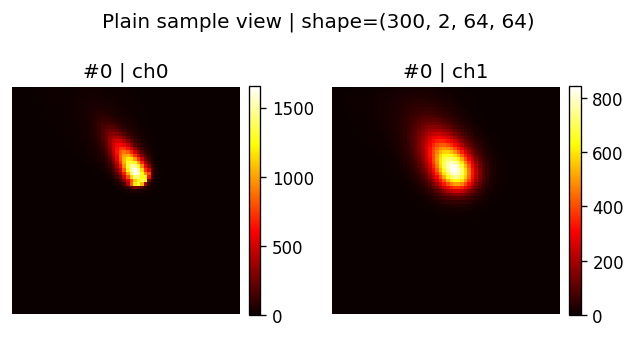

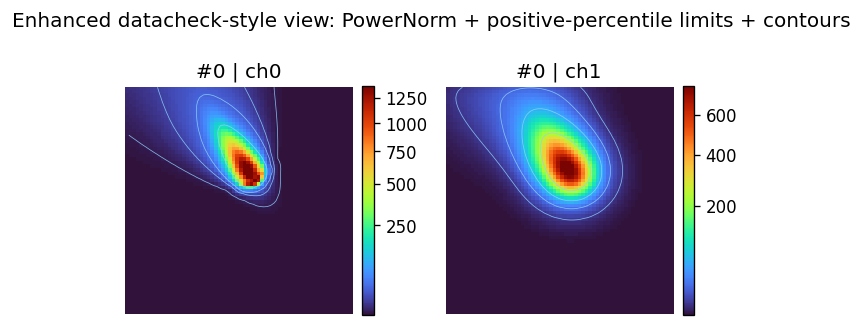

In [3]:
index = 0
show_plain_sample(data, index=index, channel_names=CHANNEL_NAMES, cmap="hot")
show_enhanced_sample(
    data,
    index=index,
    channel_names=CHANNEL_NAMES,
    cmap="turbo",
    gamma=0.55,
    floor_percentile=50,
    ceil_percentile=99.7,
    contour=True,
)

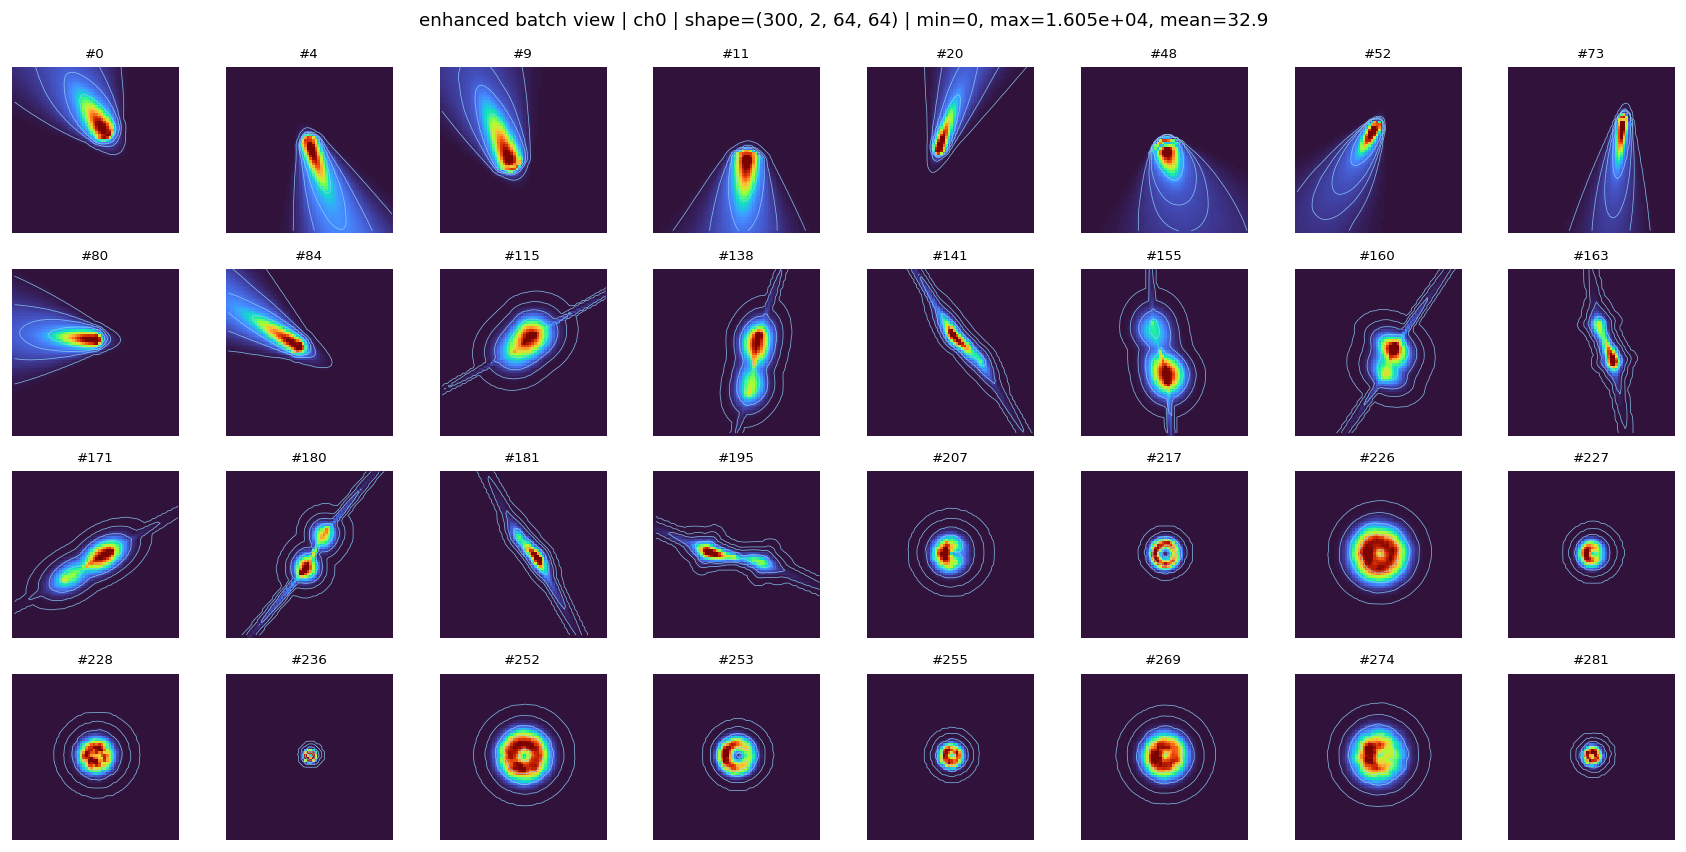

In [4]:
# 批量查看某一个 channel：mode="plain" 是朴素显示，mode="enhanced" 是 datacheck.py 风格。
show_channel_batch(
    data,
    channel=0,
    count=32,
    columns=8,
    random=True,
    seed=0,
    mode="enhanced",
    channel_names=CHANNEL_NAMES,
)